<a href="https://colab.research.google.com/github/tththththttht/Building-the-best-classifier-for-sentiment-analysis/blob/main/tetradka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Код Андрея


*   библиотека nltk
*   модель логистическая регрессия
*   текст без пунктуации





In [ ]:
!pip install pymorphy3
!pip install scikit-learn

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from string import punctuation
import nltk
import pymorphy3

In [ ]:
df = pd.read_csv("final_perekrestok_clean_dataset.csv")
df.head()
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
morph = pymorphy3.MorphAnalyzer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NameError: name 'stopwords' is not defined

In [ ]:
def obr(a):
  a = a.lower()
  for c in punctuation:
    a = a.replace(c, '')
  return a
def obr2(a):
  for c in stopwords:
    print(c)
  return a
def lem(text):
    token = nltk.word_tokenize(text)
    lemm = [morph.parse(t)[0].normal_form for t in token]
    return ' '.join(lemm)

In [ ]:
df['text'] = df['text'].apply(lambda x: obr(x))
df['text'] = df['text'].apply(lambda x: lem(x))

NameError: name 'stopwords' is not defined

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

x = df['text']
y = df['label']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=1
)
vec = TfidfVectorizer()
x_train_vec = vec.fit_transform(x_train)
x_test_vec = vec.transform(x_test)
feature_names = vec.get_feature_names_out()
print(f"Number of features: {len(feature_names)}")
clf = LogisticRegression(random_state=0).fit(x_train_vec, y_train)
y_pred = clf.predict(x_test_vec)
y_proba = clf.predict_proba(x_test_vec[:2])
print("Probabilities for first 2 samples:\n", y_proba)
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred))
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print(confusion_matrix(y_test, y_pred))
print("\n" + "="*50)
print("ACCURACY SCORE")
print("="*50)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Training Accuracy: {clf.score(x_train_vec, y_train):.4f}")

Number of features: 10129
Probabilities for first 2 samples:
 [[0.00106956 0.9948445  0.00408595]
 [0.55799449 0.17511162 0.26689389]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.56      0.56      0.56       599
           1       0.84      0.81      0.83       591
           2       0.62      0.63      0.63       610

    accuracy                           0.67      1800
   macro avg       0.67      0.67      0.67      1800
weighted avg       0.67      0.67      0.67      1800


CONFUSION MATRIX
[[338  56 205]
 [ 83 480  28]
 [187  36 387]]

ACCURACY SCORE
Test Accuracy: 0.6694
Training Accuracy: 0.8594


# Код Маши

*   библиотека spasy
*   модель дерево решений
*   просто текст с лемматизацией






In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv("final_perekrestok_clean_dataset.csv")
df.head()

,text,label,src
0,Не понравились комочки. Вкус сносный. Слишком ...,0,perekrestok
1,Могу точно сказать- это не айвар. Если б проищ...,0,perekrestok
2,"Как ни вари или в микроволновке, или укутать, ...",0,perekrestok
3,Мне этот суп не понравился. Не понравилась его...,0,perekrestok
4,"переложили сахара, на вкус сладковаты",0,perekrestok


In [ ]:
!python -m spacy download ru_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 33.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import spacy

nlp = spacy.load("ru_core_news_sm", disable=["parser", "ner"])

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    doc = nlp(text)
    clean_tokens = []

    for token in doc:
        clean_tokens.append(token.lemma_.lower())

    return " ".join(clean_tokens)

df = pd.read_csv('final_perekrestok_clean_dataset.csv')

df['clean_text'] = df['text'].apply(preprocess_text)
df.to_csv('processed_reviews.csv', index=False)



In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("processed_reviews.csv")

In [ ]:
df = df.dropna()

In [ ]:
X = df["clean_text"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)



In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree = DecisionTreeClassifier(max_depth=85)

In [ ]:
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=85)

In [ ]:
tree_predict = tree.predict(X_test)

In [ ]:
print(classification_report(y_train, tree.predict(X_train)))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      2408
           1       1.00      0.93      0.96      2403
           2       0.89      0.93      0.91      2388

    accuracy                           0.92      7199
   macro avg       0.92      0.92      0.92      7199
weighted avg       0.92      0.92      0.92      7199



In [ ]:
tree.get_depth()

85

In [ ]:
print(classification_report(y_test, tree_predict))

              precision    recall  f1-score   support

           0       0.48      0.54      0.51       592
           1       0.77      0.69      0.73       596
           2       0.59      0.58      0.59       612

    accuracy                           0.60      1800
   macro avg       0.61      0.60      0.61      1800
weighted avg       0.61      0.60      0.61      1800



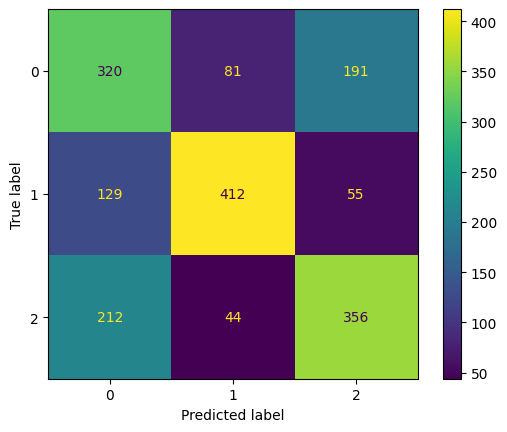

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, tree_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
# import pandas as pd
# import spacy

# nlp = spacy.load("ru_core_news_sm", disable=["parser", "ner"])

# def preprocess_text(text):
#     if not isinstance(text, str):
#         return ""

#     doc = nlp(text)
#     clean_tokens = []

#     for token in doc:
#         if not token.is_punct and not token.is_space and not token.is_stop:
#             clean_tokens.append(token.lemma_.lower())

#     return " ".join(clean_tokens)

# df = pd.read_csv('final_perekrestok_clean_dataset.csv')

# df['clean_text'] = df['text'].apply(preprocess_text)
# df.to_csv('processed_reviews.csv', index=False)

# Код Насти

In [ ]:
%pip install pymystem3 pymorphy3 nltk spacy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
!{sys.executable} -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 79.8 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
nlp = spacy.load("ru_core_news_sm")

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/wqexzsss/perekrestok/final_perekrestok_clean_dataset.csv')
df

,text,label,src
0,Не понравились комочки. Вкус сносный. Слишком ...,0,perekrestok
1,Могу точно сказать- это не айвар. Если б проищ...,0,perekrestok
2,"Как ни вари или в микроволновке, или укутать, ...",0,perekrestok
3,Мне этот суп не понравился. Не понравилась его...,0,perekrestok
4,"переложили сахара, на вкус сладковаты",0,perekrestok
...,...,...,...
8994,"Раньше брал , были сочные и спелые \nВ этот ра...",2,perekrestok
8995,Покупаю не первый раз . Очень нравится .,2,perekrestok
8996,"Туалетная бумага, которую нельзя смывать в уни...",2,perekrestok
8997,Это не грунт для орхидей. Для орхидей нужна ко...,2,perekrestok


In [ ]:
df.shape

(8999, 3)

In [ ]:
df.info

<bound method DataFrame.info of                                                    text  label          src
0     Не понравились комочки. Вкус сносный. Слишком ...      0  perekrestok
1     Могу точно сказать- это не айвар. Если б проищ...      0  perekrestok
2     Как ни вари или в микроволновке, или укутать, ...      0  perekrestok
3     Мне этот суп не понравился. Не понравилась его...      0  perekrestok
4                 переложили сахара, на вкус сладковаты      0  perekrestok
...                                                 ...    ...          ...
8994  Раньше брал , были сочные и спелые \nВ этот ра...      2  perekrestok
8995           Покупаю не первый раз . Очень нравится .      2  perekrestok
8996  Туалетная бумага, которую нельзя смывать в уни...      2  perekrestok
8997  Это не грунт для орхидей. Для орхидей нужна ко...      2  perekrestok
8998  Не всходят долго...ждём. В том году такие не в...      2  perekrestok

[8999 rows x 3 columns]>

In [ ]:
df_old = df.copy()

In [ ]:
df.head(20)

,text,label,src
0,Не понравились комочки. Вкус сносный. Слишком ...,0,perekrestok
1,Могу точно сказать- это не айвар. Если б проищ...,0,perekrestok
2,"Как ни вари или в микроволновке, или укутать, ...",0,perekrestok
3,Мне этот суп не понравился. Не понравилась его...,0,perekrestok
4,"переложили сахара, на вкус сладковаты",0,perekrestok
5,"Вкусно!но очень многомногомного масла,слишком ...",0,perekrestok
6,"Распыление действительно норм, а вот запах... ...",0,perekrestok
7,Испортился. Вкуса черной смородины практически...,0,perekrestok
8,"От люкса только цена, а так обычные огурцы",0,perekrestok
9,"Привезли мокрым, наверное, поэтому акционный.",0,perekrestok


In [ ]:
import string

def preprocess(text):
    for c in string.punctuation:
        text = text.replace(c, "")
    text = text.lower()

    lemmas = []
    for token in nlp(text):
        if not token.is_stop:
            lemmas.append(token.lemma_)

    return ' '.join(lemmas)

In [ ]:
df['text'] = df['text'].apply(preprocess)
df

,text,label,src
0,понравиться комочки вкус сносный густой 10 заг...,0,perekrestok
1,"сказать айвар проищводитель впереди добавить ""...",0,perekrestok
2,ни варя микроволновка укутать равно жёсткий гр...,0,perekrestok
3,суп понравиться понравиться консистенция вкус ...,0,perekrestok
4,переложить сахар вкус сладковаты,0,perekrestok
...,...,...,...
8994,брать сочный спелый \n раз прийти пластиковы...,2,perekrestok
8995,покупать первый раз нравиться,2,perekrestok
8996,туалетный бумага смывать унитаз,2,perekrestok
8997,грунт орхидей орхидей нужный кора мох земля др...,2,perekrestok


In [ ]:
df_old

,text,label,src
0,Не понравились комочки. Вкус сносный. Слишком ...,0,perekrestok
1,Могу точно сказать- это не айвар. Если б проищ...,0,perekrestok
2,"Как ни вари или в микроволновке, или укутать, ...",0,perekrestok
3,Мне этот суп не понравился. Не понравилась его...,0,perekrestok
4,"переложили сахара, на вкус сладковаты",0,perekrestok
...,...,...,...
8994,"Раньше брал , были сочные и спелые \nВ этот ра...",2,perekrestok
8995,Покупаю не первый раз . Очень нравится .,2,perekrestok
8996,"Туалетная бумага, которую нельзя смывать в уни...",2,perekrestok
8997,Это не грунт для орхидей. Для орхидей нужна ко...,2,perekrestok


In [ ]:
df

,text,label,src
0,понравиться комочки вкус сносный густой 10 заг...,0,perekrestok
1,"сказать айвар проищводитель впереди добавить ""...",0,perekrestok
2,ни варя микроволновка укутать равно жёсткий гр...,0,perekrestok
3,суп понравиться понравиться консистенция вкус ...,0,perekrestok
4,переложить сахар вкус сладковаты,0,perekrestok
...,...,...,...
8994,брать сочный спелый \n раз прийти пластиковы...,2,perekrestok
8995,покупать первый раз нравиться,2,perekrestok
8996,туалетный бумага смывать унитаз,2,perekrestok
8997,грунт орхидей орхидей нужный кора мох земля др...,2,perekrestok


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df['text']
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
vectorizer.get_feature_names_out()

array(['01', '010620', '02022020', ..., 'ёмкий', 'ёмкость', 'ёршик'],
      dtype=object)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logreg = LogisticRegression()

In [ ]:
logreg.fit(X_train_tfidf, y_train)

LogisticRegression()

In [ ]:
logreg_predict = logreg.predict(X_test_tfidf)
logreg_predict

array([1, 1, 1, ..., 1, 2, 2])

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, logreg_predict))

              precision    recall  f1-score   support

           0       0.55      0.58      0.57       592
           1       0.79      0.80      0.79       596
           2       0.63      0.59      0.61       612

    accuracy                           0.66      1800
   macro avg       0.66      0.66      0.66      1800
weighted avg       0.66      0.66      0.66      1800



In [ ]:
%pip install -U catboost


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100
)

In [ ]:
catboost.fit(X_train_tfidf, y_train)
catboost_predict = catboost.predict(X_test_tfidf)

0:	learn: 1.0855657	total: 107ms	remaining: 1m 47s
100:	learn: 0.8665954	total: 9.29s	remaining: 1m 22s
200:	learn: 0.8197752	total: 18.5s	remaining: 1m 13s
300:	learn: 0.7863440	total: 27.8s	remaining: 1m 4s
400:	learn: 0.7662537	total: 37s	remaining: 55.3s
500:	learn: 0.7503105	total: 46.3s	remaining: 46.1s
600:	learn: 0.7379888	total: 55.5s	remaining: 36.8s
700:	learn: 0.7264803	total: 1m 4s	remaining: 27.6s
800:	learn: 0.7161520	total: 1m 13s	remaining: 18.3s
900:	learn: 0.7073184	total: 1m 22s	remaining: 9.1s
999:	learn: 0.6997070	total: 1m 31s	remaining: 0us


In [ ]:
print(classification_report(y_test, catboost_predict))

              precision    recall  f1-score   support

           0       0.51      0.63      0.56       592
           1       0.74      0.75      0.75       596
           2       0.65      0.49      0.56       612

    accuracy                           0.62      1800
   macro avg       0.63      0.62      0.62      1800
weighted avg       0.63      0.62      0.62      1800



In [ ]:
pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained('blanchefort/rubert-base-cased-sentiment-rusentiment')
model = AutoModelForSequenceClassification.from_pretrained('blanchefort/rubert-base-cased-sentiment-rusentiment', return_dict=True)

@torch.no_grad()
def predict(text):
    inputs = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors='pt')
    outputs = model(**inputs)
    predicted = torch.nn.functional.softmax(outputs.logits, dim=1)
    predicted = torch.argmax(predicted, dim=1).numpy()
    return predicted.item()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment-rusentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
X_pred = X_test.apply(predict)

In [ ]:
X_pred

3688    0
5709    1
2954    0
7137    0
676     2
       ..
2753    0
1298    0
5282    0
740     2
3777    0
Name: text, Length: 1800, dtype: int64

In [ ]:
print(classification_report(y_test, X_pred))

              precision    recall  f1-score   support

           0       0.36      0.80      0.50       592
           1       0.63      0.36      0.46       596
           2       0.73      0.19      0.30       612

    accuracy                           0.45      1800
   macro avg       0.58      0.45      0.42      1800
weighted avg       0.58      0.45      0.42      1800



# Занятие: визуализация данных и результатов анализа тональности

## Установка библиотек

In [ ]:
!pip install -q spacy scikit-learn seaborn wordcloud
!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 50.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Импорт библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import spacy

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

## Загрузка данных

In [ ]:
df = pd.read_csv('/content/final_perekrestok_clean_dataset.csv')

df['text'] = df['text'].fillna('').astype(str)
df['label_name'] = df['label'].map({
    0: 'Нейтральные',
    1: 'Позитивные',
    2: 'Негативные'
})

print('Размер датасета:', df.shape)
print()
print(df.head().to_string())

Размер датасета: (8999, 4)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                             text  label          src   label_name
0                                                                                                                                                                                                                                                                                                      Не понравились комочки. Вкус сносный. Слишком густая для 10%. Явно загуститель использован хоть и не указан в составе. Куплю в след раз только если альтернативы не будет.      0 

## Первое знакомство с корпусом

До построения моделей важно посмотреть на реальные тексты. Тональность не всегда однозначна даже для человека: отзыв может быть коротким, смешанным или зависеть от инструкции разметчика.

In [ ]:
for label, name in [(0, 'НЕЙТРАЛЬНЫЕ'), (1, 'ПОЗИТИВНЫЕ'), (2, 'НЕГАТИВНЫЕ')]:
    print('\n' + '=' * 80)
    print(name)
    print('=' * 80)
    texts = df[df['label'] == label]['text'].sample(2, random_state=42).tolist()
    print('\n\n'.join(texts))


НЕЙТРАЛЬНЫЕ
Шампунь вызвал противоречивые чувства. С одной стороны волосы после него мягкие, плотные и блестят, но с другой - объем исчезает.

Сомневаюсь, что в крестьянский хлеб столько сахара добавляли. Приторная шляпа.

ПОЗИТИВНЫЕ
Достоинства:
Защищает от морозов

Недостатки:
Нет недостатков

Нормальный крем отличное качество

Всем рулетам рулет в плане вкуса,настолько нежный и пропитанный,что ломается в руках,равных ему по вкусу я не пробовал, Яшкино тоже хорош,но не дотягивает. Всем советую попробовать,да ещё и сочетания цены и продукта очень оптимальное.

МИНУСЫ: Состав очень химический  😔
Редко встречается на прилавках 😬

Оценку ставил за вкус

НЕГАТИВНЫЕ
Не вкусно, слишком сладкий

Очень сушит кожу, разочарование!


---
# Как устроен график?

## Figure и Axes

В `matplotlib` весь лист с графиком называется **Figure** (`fig`). Область, в которой мы рисуем конкретный график, называется **Axes** (`ax`).

На объекте `ax` мы строим данные, задаём подписи осей, заголовок, легенду и аннотации. В одном Figure может быть один Axes или несколько.

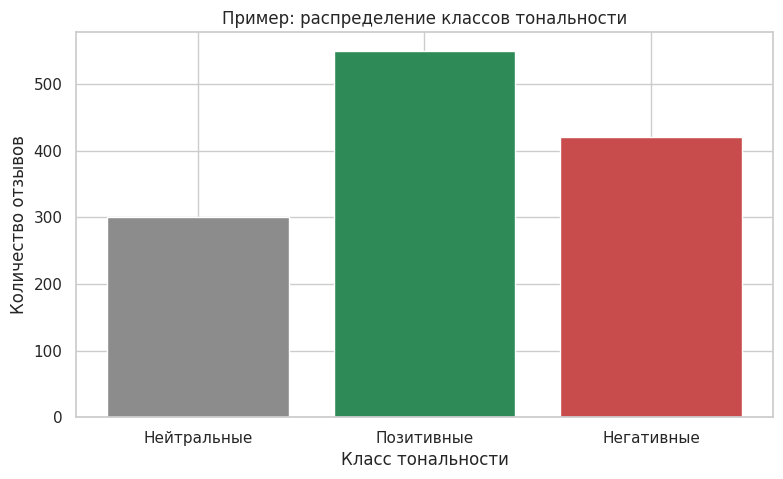

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(['Нейтральные', 'Позитивные', 'Негативные'], [300, 550, 420],
       color=['#8C8C8C', '#2E8B57', '#C94C4C'])

ax.set_title('Пример: распределение классов тональности')
ax.set_xlabel('Класс тональности')
ax.set_ylabel('Количество отзывов')

plt.show()

- `figsize=(9, 5)` задаёт размер изображения.
- `ax.bar()` строит столбчатую диаграмму.
- `ax.set_title()` задаёт заголовок.
- `ax.set_xlabel()` и `ax.set_ylabel()` подписывают оси.
- `plt.show()` выводит Figure.

Хороший заголовок не только называет тип графика, но и помогает увидеть результат.

## Аннотации

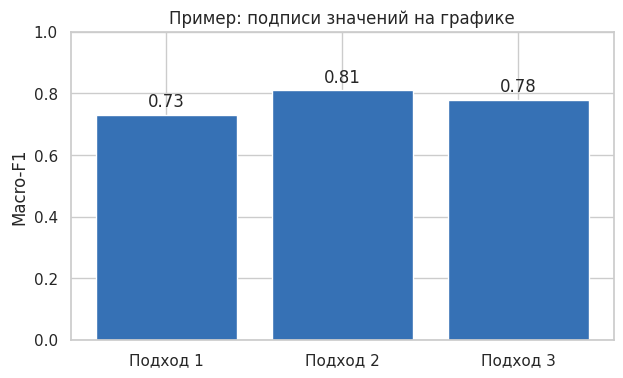

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(['Подход 1', 'Подход 2', 'Подход 3'], [0.73, 0.81, 0.78], color='#3671B5')
ax.bar_label(bars, labels=['0.73', '0.81', '0.78'], padding=3)

ax.set_ylim(0, 1)
ax.set_title('Пример: подписи значений на графике')
ax.set_ylabel('Macro-F1')

plt.show()

Аннотации полезны, если точные значения важны для вывода. Не нужно подписывать всё подряд: график не должен превращаться в таблицу.

---
# Данные до предобработки

## Распределение классов

Этот график отвечает на вопрос: сколько нейтральных, позитивных и негативных отзывов есть в датасете?

In [ ]:
class_counts = df['label_name'].value_counts().reindex(
    ['Нейтральные', 'Позитивные', 'Негативные']
)

class_share = class_counts / class_counts.sum() * 100

print(pd.DataFrame({
    'Количество': class_counts,
    'Доля, %': class_share.round(1)
}).to_string())

             Количество  Доля, %
label_name                      
Нейтральные        3000     33.3
Позитивные         2999     33.3
Негативные         3000     33.3


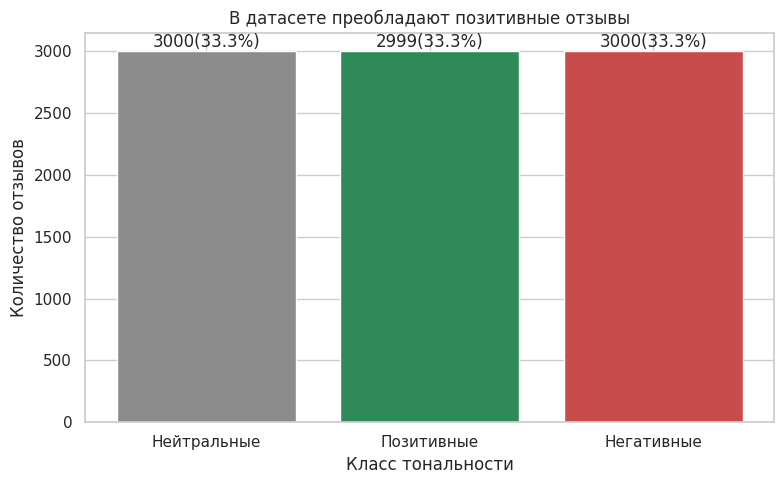

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=['#8C8C8C', '#2E8B57', '#C94C4C']
)

for bar, count, share in zip(bars, class_counts.values, class_share.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count}({share:.1f}%)',
        ha='center',
        va='bottom'
    )

ax.set_title('В датасете преобладают позитивные отзывы')
ax.set_xlabel('Класс тональности')
ax.set_ylabel('Количество отзывов')

plt.tight_layout()
plt.show()

In [ ]:
largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()

print(
    f'Ответ: самый частый класс — {largest_class.lower()} ({class_share[largest_class]:.1f}%). '
    f'Самый редкий — {smallest_class.lower()} ({class_share[smallest_class]:.1f}%). '
)

Ответ: самый частый класс — нейтральные (33.3%). Самый редкий — позитивные (33.3%). 


Достаточно ли accuracy для оценки при таких данных?

---
# Лингвистическая предобработка

## Один проход по всему корпусу

В этом блоке мы **один раз** запускаем spaCy по всем отзывам. После этого в DataFrame будут готовы: число слов, токены, леммы, содержательные леммы, очищенный текст и биграммы.

In [ ]:
nlp = spacy.load('ru_core_news_sm', disable=['parser', 'ner'])

rows = []

for doc in nlp.pipe(df['text'], batch_size=500):
    tokens = []
    lemmas = []
    content_lemmas = []

    for token in doc:
        if token.is_alpha:
            tokens.append(token.text.lower())
            lemmas.append(token.lemma_.lower())

            # Сохраняем отрицания: они важны для анализа тональности.
            if not token.is_stop or token.lemma_.lower() in {'не', 'ни', 'нет'}:
                if len(token.lemma_) >= 3 or token.lemma_.lower() in {'не', 'ни', 'нет'}:
                    content_lemmas.append(token.lemma_.lower())

    bigrams = [
        f'{content_lemmas[i]} {content_lemmas[i + 1]}'
        for i in range(len(content_lemmas) - 1)
    ]

    rows.append({
        'n_characters': len(doc.text),
        'n_words': len(tokens),
        'tokens': tokens,
        'lemmas': lemmas,
        'content_lemmas': content_lemmas,
        'preprocessed_text': ' '.join(content_lemmas),
        'bigrams': bigrams
    })

processed = pd.DataFrame(rows)
df = pd.concat([df, processed], axis=1)

print('Предобработка завершена.')
print()
print(df[['text', 'tokens', 'lemmas', 'content_lemmas', 'preprocessed_text']].head(3).to_string())

Предобработка завершена.

                                                                                                                                                                                                                                                                                                                                                                                                                                                                             text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   tokens    

### Что произошло с текстом?

- `tokens` — слова в нижнем регистре.
- `lemmas` — нормальные формы слов.
- `content_lemmas` — леммы без большинства стоп-слов.
- `preprocessed_text` — содержательные леммы, собранные обратно в строку для векторизаторов.
- Отрицания `не`, `ни`, `нет` специально сохранены: удалять их в задаче тональности опасно.

---
# Что говорят тексты?

## Длина отзывов

Histogram показывает форму распределения длины. Boxplot помогает сравнить типичную длину текстов в разных классах. Длина текста — характеристика корпуса, а не причина тональности.

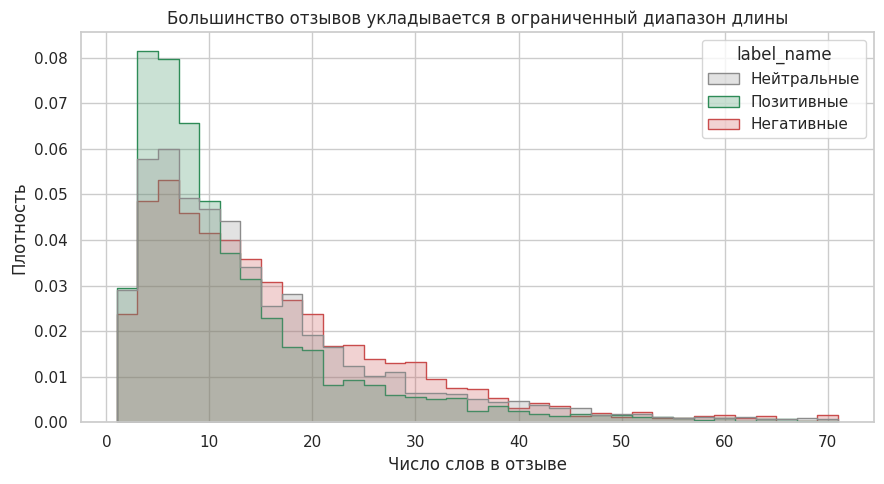

In [ ]:
upper_limit = df['n_words'].quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df[df['n_words'] <= upper_limit],
    x='n_words',
    hue='label_name',
    hue_order=['Нейтральные', 'Позитивные', 'Негативные'],
    palette={'Нейтральные': '#8C8C8C', 'Позитивные': '#2E8B57', 'Негативные': '#C94C4C'},
    bins=35,
    stat='density',
    common_norm=False,
    element='step',
    alpha=0.25,
    ax=ax
)

ax.set_title('Большинство отзывов укладывается в ограниченный диапазон длины')
ax.set_xlabel('Число слов в отзыве')
ax.set_ylabel('Плотность')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2694/2539939182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


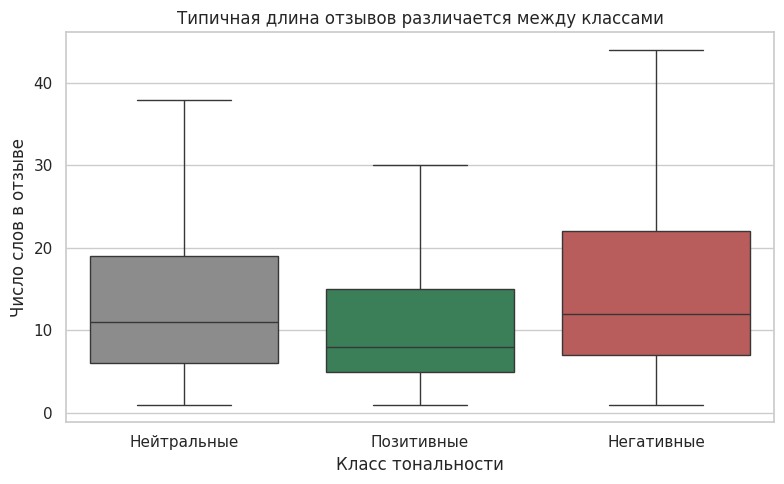

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='label_name',
    y='n_words',
    order=['Нейтральные', 'Позитивные', 'Негативные'],
    palette={'Нейтральные': '#8C8C8C', 'Позитивные': '#2E8B57', 'Негативные': '#C94C4C'},
    showfliers=False,
    ax=ax
)

ax.set_title('Типичная длина отзывов различается между классами')
ax.set_xlabel('Класс тональности')
ax.set_ylabel('Число слов в отзыве')

plt.tight_layout()
plt.show()

In [ ]:
medians = df.groupby('label_name')['n_words'].median().reindex(
    ['Нейтральные', 'Позитивные', 'Негативные']
)

print('Медианная длина отзывов:')
print(medians.round(1).to_string())

Медианная длина отзывов:
label_name
Нейтральные    11.0
Позитивные      8.0
Негативные     12.0


## Самые короткие и самые длинные отзывы

In [ ]:
print('САМЫЕ КОРОТКИЕ ОТЗЫВЫ')
print(df.nsmallest(3, 'n_words')[['label_name', 'n_words', 'text']].to_string(index=False))

print('=' * 100)

print('САМЫЕ ДЛИННЫЕ ОТЗЫВЫ')
print(df.nlargest(3, 'n_words')[['label_name', 'n_words', 'text']].to_string(index=False))

САМЫЕ КОРОТКИЕ ОТЗЫВЫ
 label_name  n_words        text
Нейтральные        1 Переслащена
Нейтральные        1   Безвкусно
Нейтральные        1   Неудобный
САМЫЕ ДЛИННЫЕ ОТЗЫВЫ
label_name  n_words                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

## Частотные леммы

Сравниваем относительную частоту на 1000 содержательных лемм. Это важнее сырых частот, потому что классы в датасете имеют разный размер.

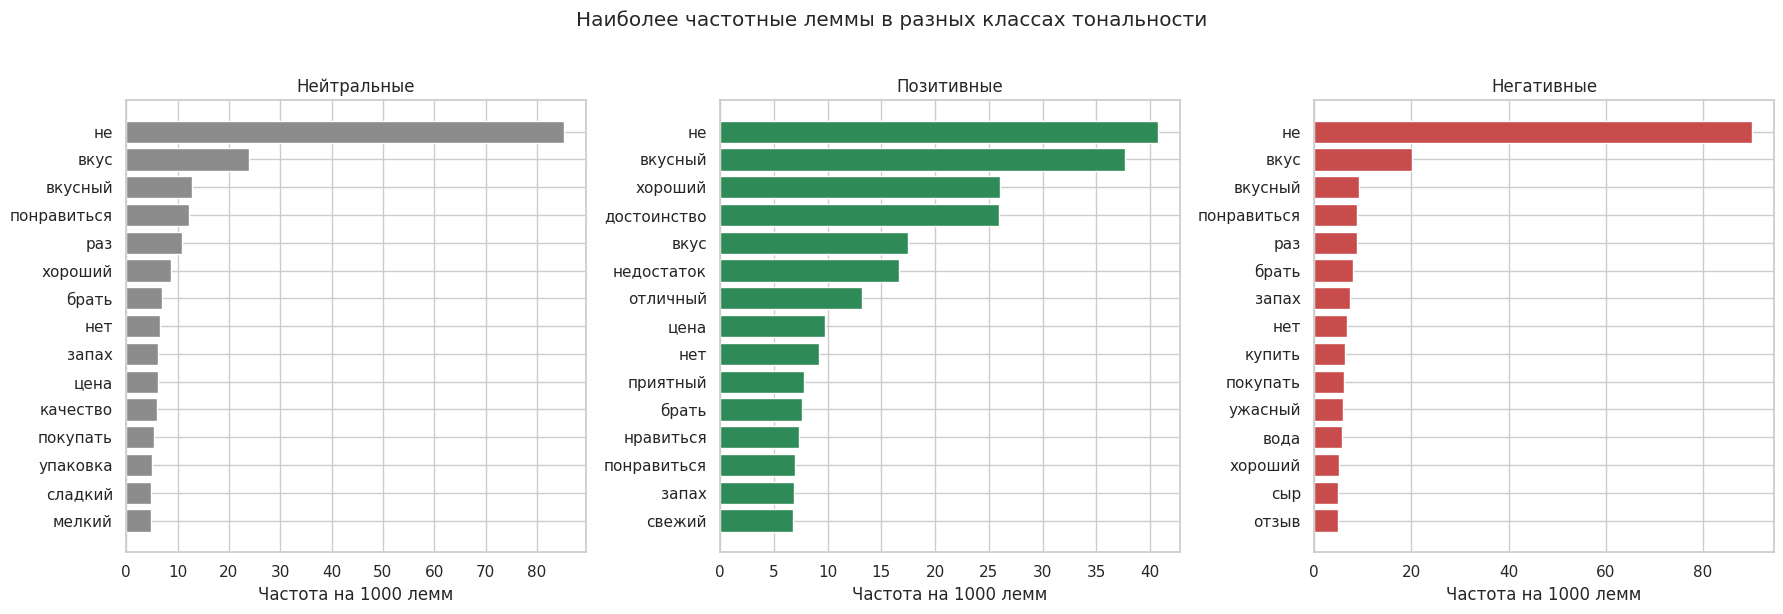

In [ ]:
def top_lemmas(label, n=15):
    lemmas = [lemma for row in df[df['label'] == label]['content_lemmas'] for lemma in row]
    counts = Counter(lemmas)
    total = sum(counts.values())

    result = pd.DataFrame(counts.most_common(n), columns=['lemma', 'count'])
    result['per_1000'] = result['count'] / total * 1000
    return result.sort_values('per_1000')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, label, name, color in zip(
    axes,
    [0, 1, 2],
    ['Нейтральные', 'Позитивные', 'Негативные'],
    ['#8C8C8C', '#2E8B57', '#C94C4C']
):
    top = top_lemmas(label)
    ax.barh(top['lemma'], top['per_1000'], color=color)
    ax.set_title(name)
    ax.set_xlabel('Частота на 1000 лемм')
    ax.set_ylabel('')

fig.suptitle('Наиболее частотные леммы в разных классах тональности', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
for label, name in [(0, 'нейтральных'), (1, 'позитивных'), (2, 'негативных')]:
    words = top_lemmas(label, 5).sort_values('per_1000', ascending=False)['lemma'].tolist()
    print(f'Пять наиболее частотных лемм в {name} отзывах: {", ".join(words)}')

Пять наиболее частотных лемм в нейтральных отзывах: не, вкус, вкусный, понравиться, раз
Пять наиболее частотных лемм в позитивных отзывах: не, вкусный, хороший, достоинство, вкус
Пять наиболее частотных лемм в негативных отзывах: не, вкус, вкусный, понравиться, раз


### Как интерпретировать этот график?

## Биграммы

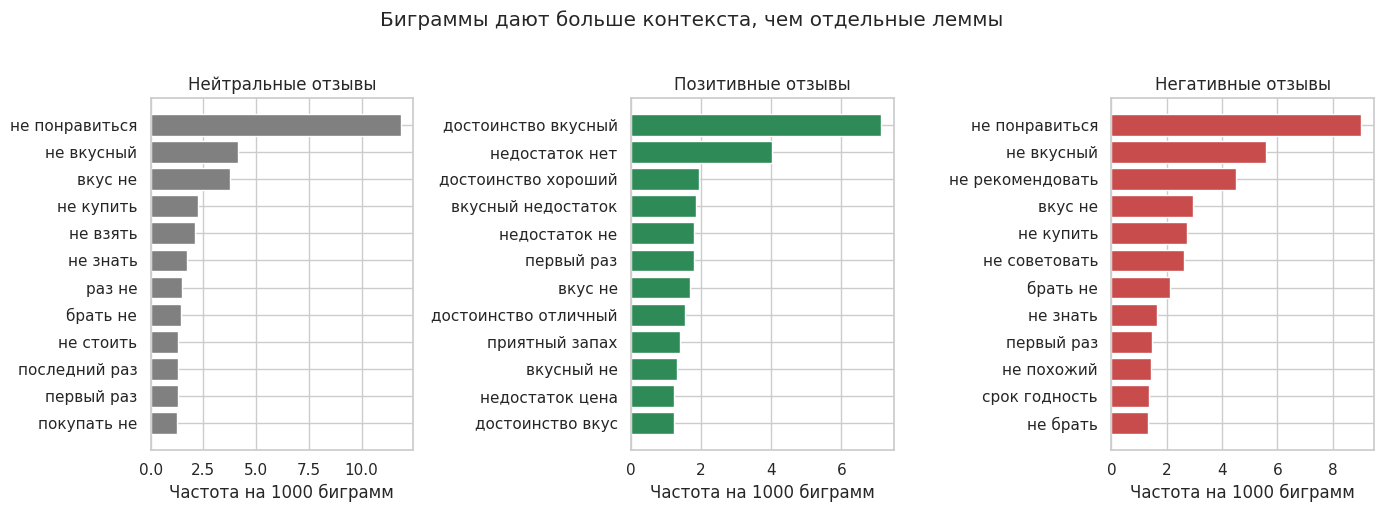

In [ ]:
def top_bigrams(label, n=12):
    bigrams = [bigram for row in df[df['label'] == label]['bigrams'] for bigram in row]
    counts = Counter(bigrams)
    total = sum(counts.values())

    result = pd.DataFrame(counts.most_common(n), columns=['bigram', 'count'])
    result['per_1000'] = result['count'] / total * 1000
    return result.sort_values('per_1000')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, label, name, color in zip(
    axes,
    [0, 1, 2],
    ['Нейтральные отзывы', 'Позитивные отзывы', 'Негативные отзывы'],
    ['gray', '#2E8B57', '#C94C4C']
):
    top = top_bigrams(label)
    ax.barh(top['bigram'], top['per_1000'], color=color)
    ax.set_title(name)
    ax.set_xlabel('Частота на 1000 биграмм')
    ax.set_ylabel('')

fig.suptitle('Биграммы дают больше контекста, чем отдельные леммы', y=1.02)
plt.tight_layout()
plt.show()

Биграммы сохраняют локальный контекст. Например, «не рекомендовать» и «быстрый доставка» могут быть содержательнее, чем слова «рекомендовать» и «доставка» по отдельности.

## Облако слов — дополнительная иллюстрация

Облако слов можно использовать как визуальное дополнение. Оно не заменяет barplot: в нём трудно сравнить точные частоты, а положение слов не несёт смысла.

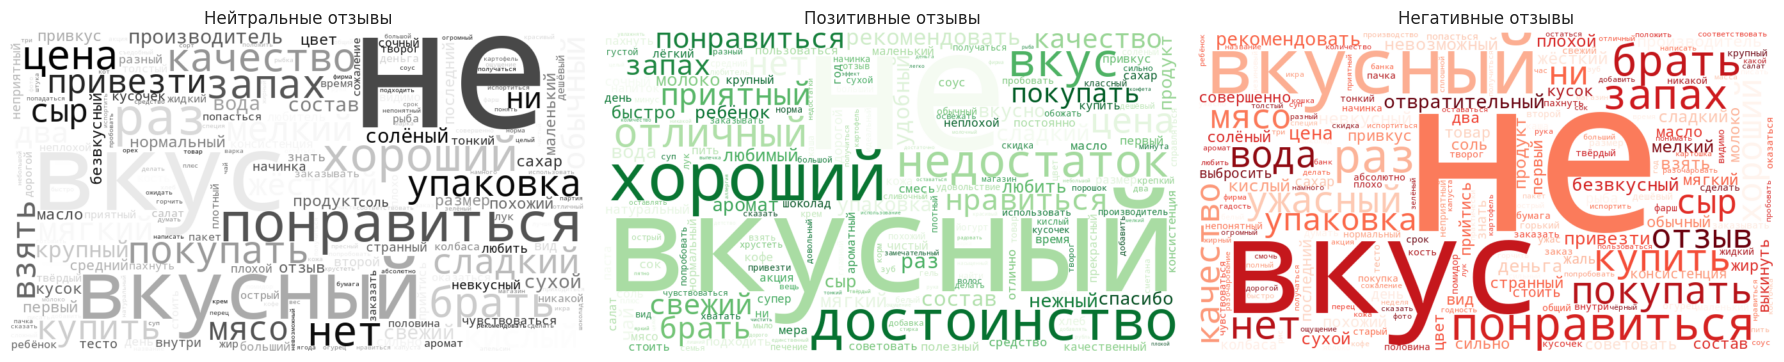

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, label, name, cmap in zip(
    axes,
    [0, 1, 2],
    ['Нейтральные отзывы', 'Позитивные отзывы', 'Негативные отзывы'],
    ['Greys', 'Greens', 'Reds']
):
    frequencies = Counter(
        lemma for row in df[df['label'] == label]['content_lemmas'] for lemma in row
    )

    cloud = WordCloud(
        width=900,
        height=500,
        background_color='white',
        colormap=cmap
    ).generate_from_frequencies(frequencies)

    ax.imshow(cloud, interpolation='bilinear')
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
# Базовые пайплайны и сравнение метрик

## Что сравниваем?

Ниже сравниваются три варианта. Во всех случаях используется один train/test split и одна модель Logistic Regression.

1. CountVectorizer на исходных текстах.
2. TF-IDF на исходных текстах.
3. TF-IDF на лемматизированных текстах без большинства стоп-слов.

Третий вариант меняет сразу несколько шагов предобработки, поэтому нельзя утверждать, что разницу вызвала только лемматизация. Корректно говорить о различии пайплайнов целиком.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df.index,
    df['label'],
    test_size=0.20,
    stratify=df['label'],
    random_state=42
)

pipelines = {
    'Count + Logistic Regression': Pipeline([
        ('vectorizer', CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=15000)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'TF-IDF + Logistic Regression': Pipeline([
        ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=15000)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'TF-IDF + предобработка + Logistic Regression': Pipeline([
        ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=15000)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ])
}

texts = {
    'Count + Logistic Regression': df.loc[X_train, 'text'],
    'TF-IDF + Logistic Regression': df.loc[X_train, 'text'],
    'TF-IDF + предобработка + Logistic Regression': df.loc[X_train, 'preprocessed_text']
}

test_texts = {
    'Count + Logistic Regression': df.loc[X_test, 'text'],
    'TF-IDF + Logistic Regression': df.loc[X_test, 'text'],
    'TF-IDF + предобработка + Logistic Regression': df.loc[X_test, 'preprocessed_text']
}

In [ ]:
results = []
predictions = {}
reports = {}

for name, pipeline in pipelines.items():
    pipeline.fit(texts[name], y_train)
    y_pred = pipeline.predict(test_texts[name])

    predictions[name] = y_pred
    reports[name] = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results.append({
        'Пайплайн': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 macro': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values('F1 macro', ascending=False)
print(results_df.round(3).to_string(index=False))

                                    Пайплайн  Accuracy  Precision macro  Recall macro  F1 macro
                TF-IDF + Logistic Regression     0.683            0.687         0.683     0.684
                 Count + Logistic Regression     0.673            0.676         0.673     0.674
TF-IDF + предобработка + Logistic Regression     0.661            0.663         0.661     0.662


## Сравнение macro-F1

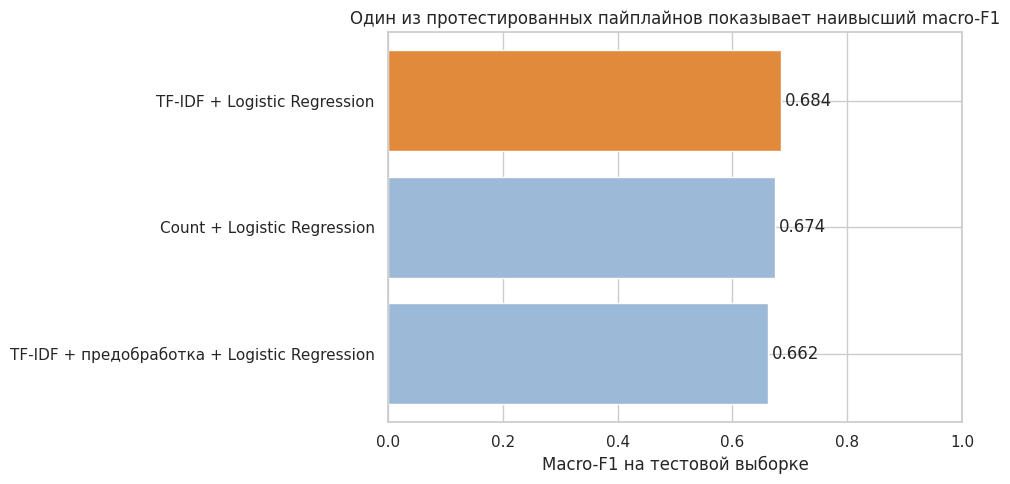

In [ ]:
plot_data = results_df.sort_values('F1 macro')
colors = ['#9DB9D8', '#9DB9D8', '#E28A3B']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_data['Пайплайн'], plot_data['F1 macro'], color=colors)
ax.bar_label(bars, labels=[f'{value:.3f}' for value in plot_data['F1 macro']], padding=3)
ax.set_xlim(0, 1)
ax.set_title('Один из протестированных пайплайнов показывает наивысший macro-F1')
ax.set_xlabel('Macro-F1 на тестовой выборке')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Сравнение precision, recall и macro-F1

Этот график нужен, когда недостаточно сказать, какой пайплайн имеет наивысший F1. Он показывает, за счёт чего различаются подходы: более точных предсказаний, более полного нахождения классов или баланса этих двух аспектов.

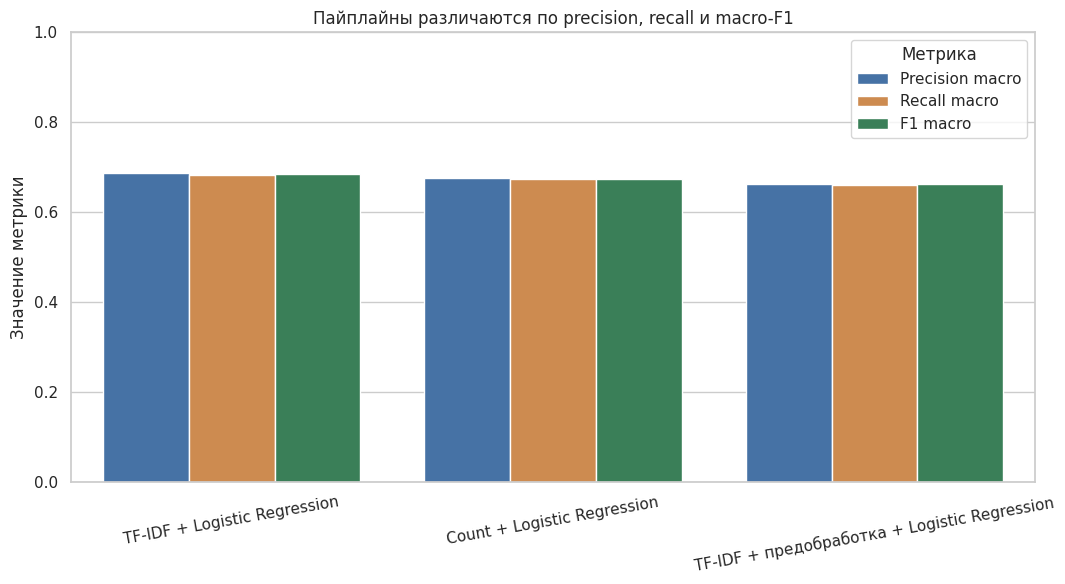

In [ ]:
metrics_for_plot = results_df.melt(
    id_vars='Пайплайн',
    value_vars=['Precision macro', 'Recall macro', 'F1 macro'],
    var_name='Метрика',
    value_name='Значение'
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=metrics_for_plot,
    x='Пайплайн',
    y='Значение',
    hue='Метрика',
    palette=['#3671B5', '#E28A3B', '#2E8B57'],
    ax=ax
)
ax.set_ylim(0, 1)
ax.set_title('Пайплайны различаются по precision, recall и macro-F1')
ax.set_xlabel('')
ax.set_ylabel('Значение метрики')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Accuracy и macro-F1

В искусственно несбалансированном датасете особенно важно сравнить accuracy и macro-F1. Если accuracy заметно выше macro-F1, модель может хорошо работать на частом позитивном классе, но хуже — на редких классах.

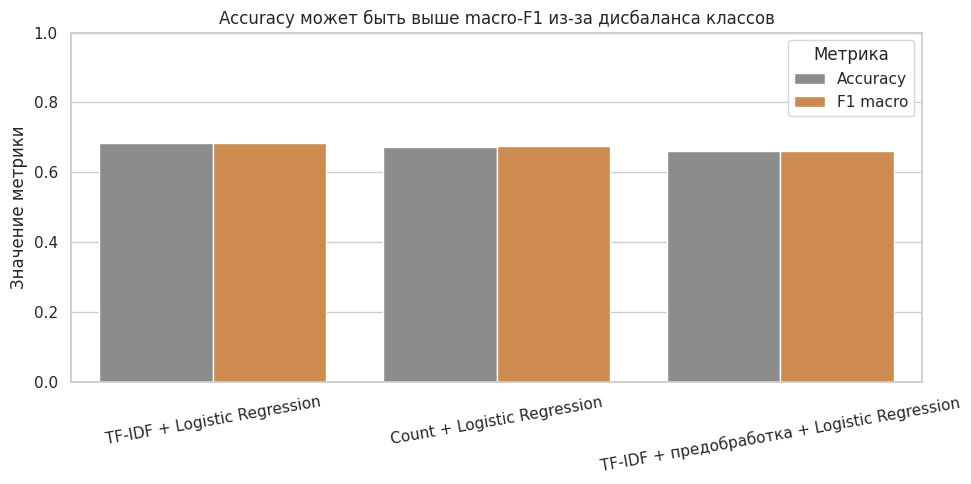

In [ ]:
metrics_for_plot = results_df.melt(
    id_vars='Пайплайн',
    value_vars=['Accuracy', 'F1 macro'],
    var_name='Метрика',
    value_name='Значение'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=metrics_for_plot,
    x='Пайплайн',
    y='Значение',
    hue='Метрика',
    palette=['#8C8C8C', '#E28A3B'],
    ax=ax
)
ax.set_ylim(0, 1)
ax.set_title('Accuracy может быть выше macro-F1 из-за дисбаланса классов')
ax.set_xlabel('')
ax.set_ylabel('Значение метрики')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Метрики по каждому классу

Macro-F1 полезна как общий показатель, но она не показывает, какой именно класс распознаётся плохо. Поэтому отдельно сравним recall классов: какую долю реальных нейтральных, позитивных и негативных отзывов нашла каждая модель.

In [ ]:
class_metrics = []

for name, report in reports.items():
    for label, class_name in [('0', 'Нейтральные'), ('1', 'Позитивные'), ('2', 'Негативные')]:
        class_metrics.append({
            'Пайплайн': name,
            'Класс': class_name,
            'Recall': report[label]['recall'],
            'F1': report[label]['f1-score']
        })

class_metrics = pd.DataFrame(class_metrics)
print(class_metrics.round(3).to_string(index=False))

                                    Пайплайн       Класс  Recall    F1
                 Count + Logistic Regression Нейтральные   0.585 0.574
                 Count + Logistic Regression  Позитивные   0.828 0.844
                 Count + Logistic Regression  Негативные   0.605 0.605
                TF-IDF + Logistic Regression Нейтральные   0.585 0.581
                TF-IDF + Logistic Regression  Позитивные   0.835 0.853
                TF-IDF + Logistic Regression  Негативные   0.628 0.620
TF-IDF + предобработка + Logistic Regression Нейтральные   0.572 0.557
TF-IDF + предобработка + Logistic Regression  Позитивные   0.823 0.829
TF-IDF + предобработка + Logistic Regression  Негативные   0.588 0.600


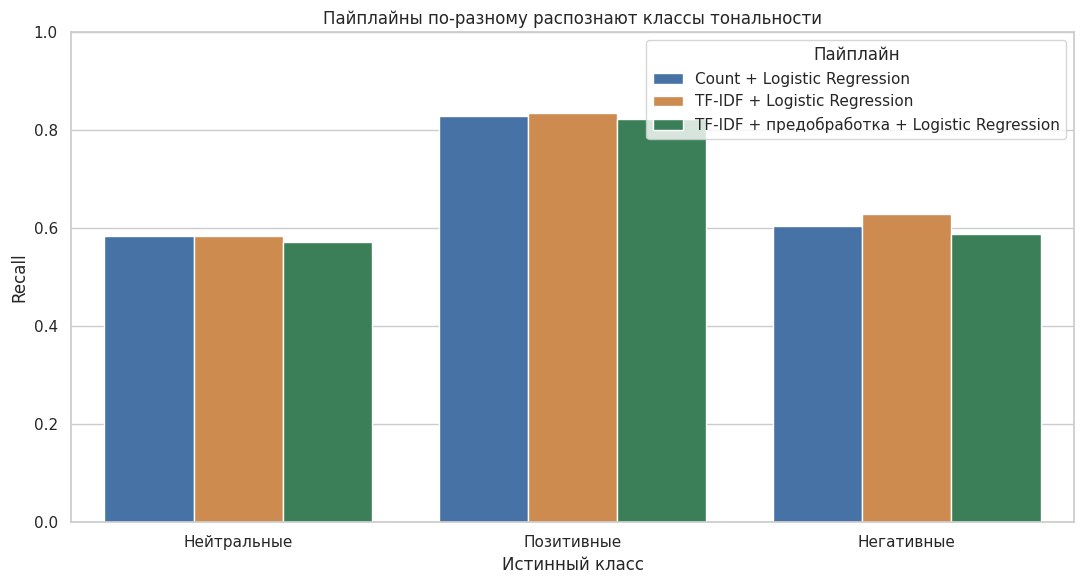

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=class_metrics,
    x='Класс',
    y='Recall',
    hue='Пайплайн',
    palette=['#3671B5', '#E28A3B', '#2E8B57'],
    ax=ax
)
ax.set_ylim(0, 1)
ax.set_title('Пайплайны по-разному распознают классы тональности')
ax.set_xlabel('Истинный класс')
ax.set_ylabel('Recall')
plt.tight_layout()
plt.show()

---
# Ошибки лучшего пайплайна

In [ ]:
best_pipeline = results_df.iloc[0]['Пайплайн']
y_pred = predictions[best_pipeline]

print('Лучший пайплайн:', best_pipeline)
print()
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=['Нейтральные', 'Позитивные', 'Негативные'],
    zero_division=0
))

Лучший пайплайн: TF-IDF + Logistic Regression

              precision    recall  f1-score   support

 Нейтральные       0.58      0.58      0.58       600
  Позитивные       0.87      0.83      0.85       600
  Негативные       0.61      0.63      0.62       600

    accuracy                           0.68      1800
   macro avg       0.69      0.68      0.68      1800
weighted avg       0.69      0.68      0.68      1800



## Confusion matrix

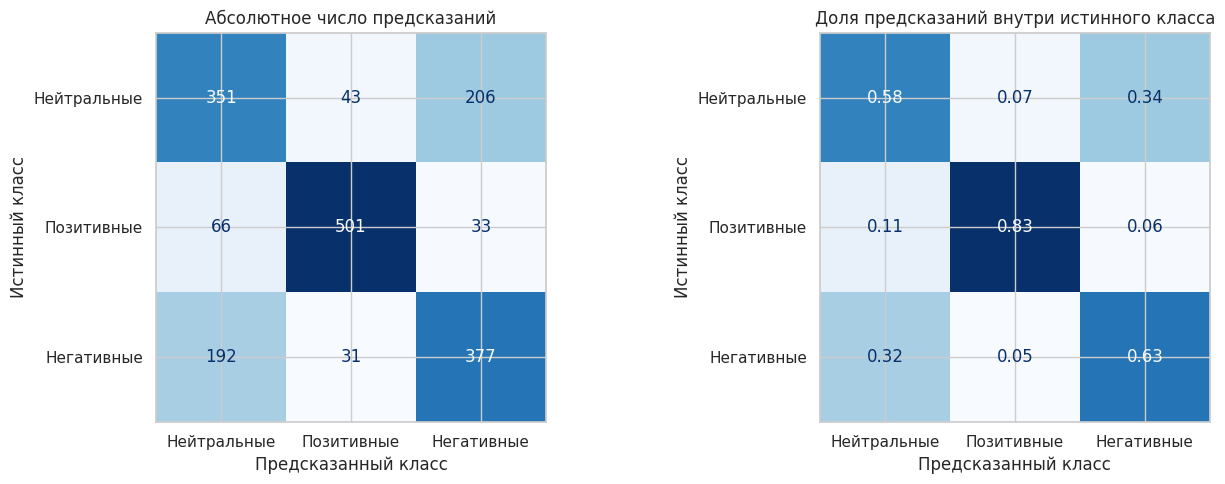

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    display_labels=['Нейтральные', 'Позитивные', 'Негативные'],
    cmap='Blues',
    values_format='d',
    colorbar=False,
    ax=axes[0]
)
axes[0].set_title('Абсолютное число предсказаний')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    display_labels=['Нейтральные', 'Позитивные', 'Негативные'],
    normalize='true',
    cmap='Blues',
    values_format='.2f',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title('Доля предсказаний внутри истинного класса')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

Первая матрица показывает число текстов. Вторая показывает долю ошибок внутри каждого истинного класса. При дисбалансе классов нужны обе: абсолютные числа и относительные доли отвечают на разные вопросы.

/tmp/ipykernel_2694/229763684.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


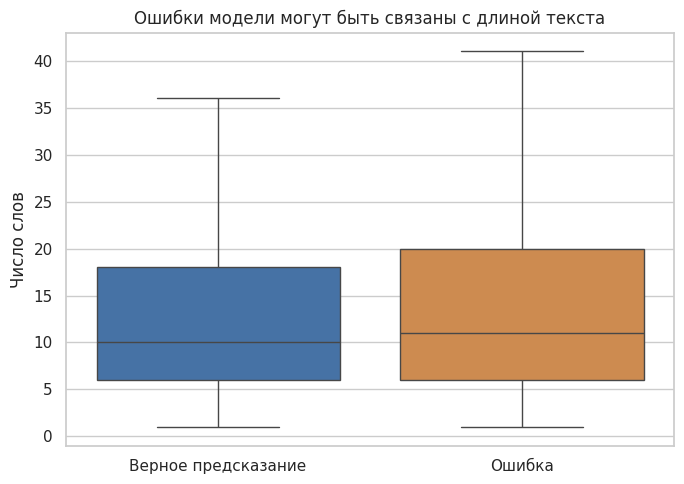

In [ ]:
errors = pd.DataFrame({
    'text': df.loc[X_test, 'text'],
    'true_label': y_test,
    'predicted_label': y_pred
})

errors['correct'] = errors['true_label'] == errors['predicted_label']
errors['result'] = errors['correct'].map({True: 'Верное предсказание', False: 'Ошибка'})
errors['n_words'] = df.loc[X_test, 'n_words']

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=errors,
    x='result',
    y='n_words',
    order=['Верное предсказание', 'Ошибка'],
    palette={'Верное предсказание': '#3671B5', 'Ошибка': '#E28A3B'},
    showfliers=False,
    ax=ax
)
ax.set_title('Ошибки модели могут быть связаны с длиной текста')
ax.set_xlabel('')
ax.set_ylabel('Число слов')
plt.tight_layout()
plt.show()

In [ ]:
median_correct = errors[errors['correct']]['n_words'].median()
median_error = errors[~errors['correct']]['n_words'].median()

print('Медианная длина верных предсказаний:', round(median_correct, 1))
print('Медианная длина ошибочных предсказаний:', round(median_error, 1))
print()
print('Ответ: этот график показывает описательную связь между длиной текста и ошибкой. Он не доказывает, что длина является причиной ошибки модели.')

Медианная длина верных предсказаний: 10.0
Медианная длина ошибочных предсказаний: 11.0

Ответ: этот график показывает описательную связь между длиной текста и ошибкой. Он не доказывает, что длина является причиной ошибки модели.


## Примеры ошибок

In [ ]:
wrong = errors[~errors['correct']].copy()
wrong['Истинный класс'] = wrong['true_label'].map({0: 'Нейтральные', 1: 'Позитивные', 2: 'Негативные'})
wrong['Предсказанный класс'] = wrong['predicted_label'].map({0: 'Нейтральные', 1: 'Позитивные', 2: 'Негативные'})

print(wrong[['text', 'Истинный класс', 'Предсказанный класс', 'n_words']].head(10).to_string(index=False))

                                                                                                                                                                                                                                                                 text Истинный класс Предсказанный класс  n_words
                                                                    Это не камамбер с мёдом. Это камамбер и упаковочка мёда. Сейчас середина декабря, а мёд не севший, хотя написано цветочный, поэтому есть сомнения, что это мёд. Сыр вполне обычный, даже хороший.    Нейтральные          Негативные       31
                                                                                                                                                                                   Торт обыкновенный, в отличие от "Полета" этой фирмы, который ну просто супер-супер    Нейтральные          Позитивные       13
                                                                                  